# Vision-GPT V1: Multimodal Image Captioning Baseline

This notebook implements **Version 1 (V1)** of the multimodal GPT-2 Vision-Language Model developed for **Smart India Hackathon 2025**.

### Architectural Overview & Features
- **Language Model Backbone**: Frozen GPT-2 Small (124M parameters).
- **Vision Encoder**: Frozen Vision Transformer (`vit_b_16`, ImageNet-1K pretrained, 87M parameters).
- **Multimodal Adapter**: Trainable **Perceiver Resampler** (64 latent tokens, 2 depth blocks) + **Sparse Cross-Attention** (spliced before GPT-2 layers 3, 6, and 9).
- **Dataset**: Flickr8k (8,000 images, 40,000 image-caption pairs).
- **Parameter Efficiency**: 11.08M trainable parameters out of 222.09M total (~5%).


## 1. Imports & Environment Setup
Import required libraries for PyTorch, torchvision, Hugging Face `datasets` and `transformers`.

In [ ]:
import os
import json
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torchvision import transforms
from datasets import load_dataset, Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image as PILImage
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import numpy as np

## 2. Core Building Blocks

Custom implementation of LayerNorm, GELU activation, FeedForward network, and Causal Multi-Head Attention for the GPT-2 backbone.


In [ ]:
# --- Core building blocks (LayerNorm, GELU, FFN, causal MHA) ---
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / math.pi, device=x.device, dtype=x.dtype)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        # causal mask
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, t, _ = x.shape
        q = self.W_query(x)
        k = self.W_key(x)
        v = self.W_value(x)
        q = q.view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        attn_scores = q @ k.transpose(2, 3)
        mask_bool = self.mask.bool()[:t, :t]
        attn_scores.masked_fill_(mask_bool, float('-inf'))
        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)
        attn_weights = self.dropout(attn_weights)
        context_vec = (attn_weights @ v).transpose(1, 2).contiguous().view(b, t, self.d_out)
        return self.out_proj(context_vec)

## 3. Sparse Cross-Attention Fusion Block

Cross-attention block allowing language token representations to attend directly to visual tokens extracted from the image.


In [3]:
# --- Cross-attention block (no mask) ---
class Cross_MultiHead_Attention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, context):
        b, t_q, _ = x.shape
        t_ctx = context.shape[1]
        q = self.W_query(x)
        k = self.W_key(context)
        v = self.W_value(context)
        q = q.view(b, t_q, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(b, t_ctx, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(b, t_ctx, self.num_heads, self.head_dim).transpose(1, 2)
        attn_scores = q @ k.transpose(2, 3)
        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)
        attn_weights = self.dropout(attn_weights)
        context_vec = (attn_weights @ v).transpose(1, 2).contiguous().view(b, t_q, self.d_out)
        return self.out_proj(context_vec)

class cross_attn_Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = Cross_MultiHead_Attention(
            d_in=cfg["emb_dim"], d_out=cfg["emb_dim"], context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], dropout=cfg["drop_rate"], qkv_bias=cfg["qkv_bias"]
        )
        self.attn_norm = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x, context):
        shortcut = x
        x = self.attn_norm(x)
        x = self.att(x, context)
        x = self.drop_shortcut(x)
        return x + shortcut

## 4. Transformer Decoder Block

Combines self-attention and feed-forward networks into a standard pre-norm Transformer layer.


In [4]:
# --- Transformer block ---
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"], d_out=cfg["emb_dim"], context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], dropout=cfg["drop_rate"], qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        return x + shortcut

## 5. Vision Encoder & Perceiver Resampler

Vision Transformer (`vit_b_16`) patch extraction and Perceiver Resampler compressing 196 patch tokens into 64 latent visual tokens.


In [5]:
# --- Vision encoder + Perceiver Resampler + VisionAdapter ---
class TorchvisionViTEncoder(nn.Module):
    def __init__(self, arch="vit_b_16", pretrained=True, freeze=True):
        super().__init__()
        if arch == "vit_b_16":
            weights = ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None
            base = vit_b_16(weights=weights)
        else:
            raise ValueError("Only vit_b_16 is implemented here.")
        self.model = base
        self.hidden_dim = base.hidden_dim
        if freeze:
            for p in self.parameters():
                p.requires_grad = False

    @torch.no_grad()
    def forward(self, images):
        features = self.model._process_input(images)  # (b, n, d)
        b, n, _ = features.shape
        cls_token = self.model.class_token.expand(b, -1, -1)
        x = torch.cat((cls_token, features), dim=1)
        x = self.model.encoder(x)
        patch_tokens = x[:, 1:, :]  # drop cls
        return patch_tokens

class PerceiverResampler(nn.Module):
    def __init__(self, dim, depth=2, num_latents=64, heads=8, dim_head=64, mlp_dim=256, dropout=0.0):
        super().__init__()
        self.latents = nn.Parameter(torch.randn(num_latents, dim))
        self.depth = depth
        self.heads = heads
        self.scale = (dim_head) ** -0.5
        self.to_q = nn.ModuleList([nn.Linear(dim, heads * dim_head, bias=False) for _ in range(depth)])
        self.to_kv = nn.ModuleList([nn.Linear(dim, heads * dim_head * 2, bias=False) for _ in range(depth)])
        self.proj_out = nn.ModuleList([nn.Linear(heads * dim_head, dim, bias=False) for _ in range(depth)])
        self.norms_latent = nn.ModuleList([nn.LayerNorm(dim) for _ in range(depth)])
        self.norms_media  = nn.ModuleList([nn.LayerNorm(dim) for _ in range(depth)])
        self.mlp = nn.ModuleList([
            nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, mlp_dim), nn.GELU(), nn.Linear(mlp_dim, dim), nn.Dropout(dropout))
            for _ in range(depth)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, media_seq):
        b, t, d = media_seq.shape
        x = self.latents.unsqueeze(0).expand(b, -1, -1)
        for i in range(self.depth):
            q = self.to_q[i](self.norms_latent[i](x))
            kv = self.to_kv[i](self.norms_media[i](media_seq))
            k, v = kv.chunk(2, dim=-1)
            h = self.heads
            dh = q.shape[-1] // h
            q = q.view(b, -1, h, dh).transpose(1, 2)
            k = k.view(b, -1, h, dh).transpose(1, 2)
            v = v.view(b, -1, h, dh).transpose(1, 2)
            attn = (q @ k.transpose(-2, -1)) * self.scale
            attn = attn.softmax(dim=-1)
            out = attn @ v
            out = out.transpose(1, 2).contiguous().view(b, -1, h * dh)
            out = self.proj_out[i](out)
            x = x + self.dropout(out)
            x = x + self.mlp[i](x)
        return x

class VisionProjector(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.proj = nn.Identity() if in_dim == out_dim else nn.Linear(in_dim, out_dim)
    def forward(self, x):
        return self.proj(x)

class VisionAdapter(nn.Module):
    def __init__(self, emb_dim, num_latents=64, perceiver_depth=2, perceiver_heads=8, perceiver_dim_head=64, dropout=0.0,
                encoder_type="torchvision_vit_b_16", pretrained=True, freeze=True):
        super().__init__()
        if encoder_type == "torchvision_vit_b_16":
            self.encoder = TorchvisionViTEncoder("vit_b_16", pretrained=pretrained, freeze=freeze)
            vision_dim = self.encoder.hidden_dim
            self.preprocess = ViT_B_16_Weights.IMAGENET1K_V1.transforms() if pretrained else None
        else:
            raise ValueError("Unsupported encoder_type")
        self.project = VisionProjector(vision_dim, emb_dim)
        self.resampler = PerceiverResampler(dim=emb_dim, depth=perceiver_depth, num_latents=num_latents,
                                            heads=perceiver_heads, dim_head=perceiver_dim_head, dropout=dropout)
    def forward(self, images):
        feats = self.encoder(images)
        feats = self.project(feats)
        visual_tokens = self.resampler(feats)
        return visual_tokens

## 6. GPTModal Model Assembly

Assembles the full multimodal architecture (`GPTModal`), inserting cross-attention blocks at designated layers (3, 6, 9).


In [6]:
# --- GPTModal with optional vision injection at specified layers ---
class GPTModal(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.ModuleList([])
        for i in range(cfg["n_layers"]):
            if i in cfg["cross_attention_pos"]:
                self.trf_blocks.append(cross_attn_Block(cfg))
            self.trf_blocks.append(TransformerBlock(cfg))
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)
        self.vision_enabled = cfg.get("vision_enabled", True)
        if self.vision_enabled:
            self.vision = VisionAdapter(
                emb_dim=cfg["emb_dim"],
                num_latents=cfg.get("perceiver_num_latents", 64),
                perceiver_depth=cfg.get("perceiver_depth", 2),
                perceiver_heads=cfg.get("perceiver_heads", 8),
                perceiver_dim_head=cfg.get("perceiver_dim_head", 64),
                dropout=cfg.get("drop_rate", 0.0),
                encoder_type=cfg.get("vision_encoder_type", "torchvision_vit_b_16"),
                pretrained=cfg.get("vision_pretrained", True),
                freeze=cfg.get("vision_freeze", True)
            )
        else:
            self.vision = None

    def forward(self, in_idx, images=None):
      device = in_idx.device
      b, T = in_idx.shape
      pos = torch.arange(T, device=device, dtype=torch.long)
      tok = self.tok_emb(in_idx)                    # (B, T, D)
      pos_emb = self.pos_emb(pos).unsqueeze(0)      # (1, T, D) broadcast over batch
      x = tok + pos_emb
      x = self.drop_emb(x)

      visual_context = None
      if self.vision is not None and images is not None:
          images = images.to(device)
          visual_context = self.vision(images)      # (B, L, D)

      for layer in self.trf_blocks:
          if isinstance(layer, TransformerBlock):
              x = layer(x)
          elif isinstance(layer, cross_attn_Block) and visual_context is not None:
              x = layer(x, visual_context)

      x = self.final_norm(x)
      logits = self.out_head(x)
      return logits

## 7. Model Freezing Utilities & Parameter Breakdown

Utility functions to freeze pretrained GPT-2 text backbone and vision encoder weights while keeping cross-attention and resampler trainable.


In [7]:
# --- Freeze utilities and parameter counting ---
def freeze_gpt_text_backbone(gpt, freeze_embeddings=True, freeze_transformer_blocks=True, freeze_final_ln=True, freeze_lm_head=True):
    if freeze_embeddings:
        for p in gpt.tok_emb.parameters(): p.requires_grad = False
        for p in gpt.pos_emb.parameters(): p.requires_grad = False
    if freeze_transformer_blocks:
        for blk in gpt.trf_blocks:
            if isinstance(blk, TransformerBlock):
                for p in blk.parameters():
                    p.requires_grad = False
    if freeze_final_ln:
        for p in gpt.final_norm.parameters(): p.requires_grad = False
    if freeze_lm_head:
        for p in gpt.out_head.parameters(): p.requires_grad = False

def count_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,}")
    print(f"Total params:     {total:,}")
    return trainable, total

## 8. Configuration & Model Instantiation

Define hyperparameters (embedding dimension 768, 12 layers, 12 heads, learning rate 1e-4) and instantiate model on GPU.


In [8]:
#  --- Config and model instantiation ---
cfg = {
    "vocab_size": 50257,          # GPT-2
    "emb_dim": 768,               # GPT-2 small
    "context_length": 256,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": True,
    "cross_attention_pos": [3, 6, 9],  # insert cross-attn before these TransformerBlocks

    "vision_enabled": True,
    "vision_encoder_type": "torchvision_vit_b_16",
    "vision_pretrained": True,
    "vision_freeze": True,

    "perceiver_num_latents": 64,
    "perceiver_depth": 2,
    "perceiver_heads": 8,
    "perceiver_dim_head": 64,

    "weight_decay": 0.01,
    "learning_rate": 1e-4,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt = GPTModal(cfg).to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 62.7MB/s]


## 9. Pretrained Weight Transfer & Vocab Expansion

Load pretrained OpenAI GPT-2 weights from Hugging Face, pad tokenizer vocabulary (`<|pad|>`), and adapt embedding layer matrices.


In [ ]:
# --- Model Loading ---
# Fix vocabulary size mismatch
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": "<|pad|>"})

# Update config to match actual vocab size
cfg["vocab_size"] = len(tokenizer)

# model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt = GPTModal(cfg).to(device)

# Load GPT-2 weights with proper device handling
hf = GPT2LMHeadModel.from_pretrained("gpt2")
sd = hf.state_dict()
params = {k: v.cpu().numpy() for k, v in sd.items()}

# Copy original embeddings and add random initialization for new pad token
original_embeddings = torch.tensor(params['transformer.wte.weight'], device=device)
new_embeddings = torch.randn(cfg["vocab_size"], cfg["emb_dim"], device=device) * 0.02
new_embeddings[:original_embeddings.size(0)] = original_embeddings
gpt.tok_emb.weight = nn.Parameter(new_embeddings)

# Keep position embeddings as before - move to device
gpt.pos_emb.weight = nn.Parameter(torch.tensor(params['transformer.wpe.weight'], device=device))

# Load transformer blocks (unchanged from your original code but ensure device placement)
trf_only = [blk for blk in gpt.trf_blocks if isinstance(blk, TransformerBlock)]
for i, blk in enumerate(trf_only):
    w_qkv = params[f'transformer.h.{i}.attn.c_attn.weight']
    b_qkv = params[f'transformer.h.{i}.attn.c_attn.bias']
    q_w, k_w, v_w = np.split(w_qkv, 3, axis=-1)
    q_b, k_b, v_b = np.split(b_qkv, 3, axis=-1)

    blk.att.W_query.weight = nn.Parameter(torch.tensor(q_w.T, device=device))
    blk.att.W_key.weight   = nn.Parameter(torch.tensor(k_w.T, device=device))
    blk.att.W_value.weight = nn.Parameter(torch.tensor(v_w.T, device=device))
    blk.att.W_query.bias   = nn.Parameter(torch.tensor(q_b, device=device))
    blk.att.W_key.bias     = nn.Parameter(torch.tensor(k_b, device=device))
    blk.att.W_value.bias   = nn.Parameter(torch.tensor(v_b, device=device))

    blk.att.out_proj.weight = nn.Parameter(torch.tensor(params[f'transformer.h.{i}.attn.c_proj.weight'].T, device=device))
    blk.att.out_proj.bias   = nn.Parameter(torch.tensor(params[f'transformer.h.{i}.attn.c_proj.bias'], device=device))

    blk.ff.layers[0].weight = nn.Parameter(torch.tensor(params[f'transformer.h.{i}.mlp.c_fc.weight'].T, device=device))
    blk.ff.layers[0].bias   = nn.Parameter(torch.tensor(params[f'transformer.h.{i}.mlp.c_fc.bias'], device=device))
    blk.ff.layers[2].weight = nn.Parameter(torch.tensor(params[f'transformer.h.{i}.mlp.c_proj.weight'].T, device=device))
    blk.ff.layers[2].bias   = nn.Parameter(torch.tensor(params[f'transformer.h.{i}.mlp.c_proj.bias'], device=device))

    blk.norm1.scale = nn.Parameter(torch.tensor(params[f'transformer.h.{i}.ln_1.weight'], device=device))
    blk.norm1.shift = nn.Parameter(torch.tensor(params[f'transformer.h.{i}.ln_1.bias'], device=device))
    blk.norm2.scale = nn.Parameter(torch.tensor(params[f'transformer.h.{i}.ln_2.weight'], device=device))
    blk.norm2.shift = nn.Parameter(torch.tensor(params[f'transformer.h.{i}.ln_2.bias'], device=device))

# Load final layer norm - move to device
gpt.final_norm.scale = nn.Parameter(torch.tensor(params['transformer.ln_f.weight'], device=device))
gpt.final_norm.shift = nn.Parameter(torch.tensor(params['transformer.ln_f.bias'], device=device))

# Tie embeddings (use the new expanded embedding matrix)
gpt.out_head.weight = gpt.tok_emb.weight

print(f"Model successfully loaded on {device}")
print(f"Vocab size: {cfg['vocab_size']}")
print(f"Embedding matrix device: {gpt.tok_emb.weight.device}")
print(f"Position embedding device: {gpt.pos_emb.weight.device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model successfully loaded on cuda
Vocab size: 50258
Embedding matrix device: cuda:0
Position embedding device: cuda:0


## 10. Dataset Pipeline (Flickr8k)

Custom PyTorch Dataset & DataLoader to load Flickr8k parquet splits and apply ViT image normalization and text tokenization.


In [ ]:
# Load all 4 parquet files for training
parquet_files = [
    "hf://datasets/jxie/flickr8k@main/data/test-00000-of-00001-42a2661d12c73e48.parquet",
    "hf://datasets/jxie/flickr8k@main/data/train-00000-of-00002-2f8f6bfa852eac4b.parquet",
    "hf://datasets/jxie/flickr8k@main/data/train-00001-of-00002-2173151d8cd6c7fb.parquet",
    "hf://datasets/jxie/flickr8k@main/data/validation-00000-of-00001-7025a2b596f14b7b.parquet"
]
hf_ds = load_dataset("parquet", data_files=parquet_files, split="train")
hf_ds = hf_ds.cast_column("image", Image())  # PIL decode

# ViT-B/16 transforms with proper grayscale handling
image_tx = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda x: x.convert('RGB')),  # Convert grayscale to RGB
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

# GPT-2 tokenizer with pad token - HANDLE VOCAB SIZE MISMATCH
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({"pad_token": "<|pad|>"})

# After adding tokens, ensure embedding matrices match tokenizer size
new_vocab_size = len(tokenizer)
if new_vocab_size != gpt.tok_emb.num_embeddings:
    print(f"Resizing embeddings: {gpt.tok_emb.num_embeddings} -> {new_vocab_size}")
    old_weight = gpt.tok_emb.weight.data
    old_vocab_size, emb_dim = old_weight.shape
    new_weight = torch.empty(new_vocab_size, emb_dim, device=old_weight.device, dtype=old_weight.dtype)
    new_weight[:old_vocab_size] = old_weight
    nn.init.normal_(new_weight[old_vocab_size:], mean=0.0, std=0.02)
    gpt.tok_emb.weight = nn.Parameter(new_weight)
    # Re-tie LM head by reference after resize
    gpt.out_head.weight = gpt.tok_emb.weight
    cfg["vocab_size"] = new_vocab_size  # keep config in sync

# Special token ids and pad id
bos_id = tokenizer.bos_token_id
eos_id = tokenizer.eos_token_id
if bos_id is None:
    bos_id = eos_id  # fallback
assert bos_id is not None and eos_id is not None, "Tokenizer must have BOS/EOS"
assert bos_id < len(tokenizer) and eos_id < len(tokenizer), "Special IDs out of range"

pad_id = tokenizer.pad_token_id
assert pad_id is not None and pad_id < len(tokenizer), "Pad token must be set and in range"

class CocoParquetDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset, tokenizer, context_length, image_transform):
        self.ds = hf_dataset
        self.tok = tokenizer
        self.ctx = context_length
        self.image_tx = image_transform

    def __len__(self):
        return len(self.ds) * 5  # 5 captions per image

    def __getitem__(self, idx):
        try:
            image_idx = idx // 5  # Which image
            caption_idx = idx % 5  # Which caption (0-4)

            ex = self.ds[image_idx]
            pil = ex["image"]         # PIL.Image.Image
            cap = ex[f"caption_{caption_idx}"]  # caption_0 through caption_4

            # Handle potential image loading issues
            if pil is None or pil.size == (0, 0):
                # Return a dummy black image if there's an issue
                pil = PILImage.new('RGB', (224, 224), color='black')

            img_t = self.image_tx(pil)

            # Encode caption with BOS ... EOS and truncate to context
            ids = [bos_id] + self.tok.encode(cap, add_special_tokens=False) + [eos_id]
            ids = ids[:self.ctx]

            return {
                "input_ids": torch.tensor(ids, dtype=torch.long),
                "image": img_t
            }
        except Exception as e:
            print(f"Error processing sample {idx}: {e}")
            # Return a fallback sample
            dummy_img = torch.zeros(3, 224, 224)  # RGB dummy image
            dummy_ids = [bos_id, eos_id]
            return {
                "input_ids": torch.tensor(dummy_ids, dtype=torch.long),
                "image": dummy_img
            }

def collate_fn(batch, pad_id=0, ctx=256, vocab_size=None):
    imgs = torch.stack([b["image"] for b in batch], dim=0)
    seqs = [b["input_ids"] for b in batch]

    def pad_to_ctx(seq):
        if seq.numel() >= ctx:
            s = seq[:ctx]
        else:
            s = torch.cat([seq, torch.full((ctx - seq.numel(),), pad_id, dtype=seq.dtype)], dim=0)
        if vocab_size is not None:
            s = torch.clamp(s, 0, vocab_size - 1)  # safety against out-of-range ids
        return s

    input_ids = torch.stack([pad_to_ctx(s) for s in seqs], dim=0)
    # Build labels as next-token targets; ignore padding in loss
    labels = input_ids.clone()
    labels[:, :-1] = input_ids[:, 1:]
    labels[:, -1] = pad_id
    labels[labels == pad_id] = -100
    return {"input_ids": input_ids, "labels": labels, "images": imgs}

context_length = cfg["context_length"]
train_ds = CocoParquetDataset(hf_ds, tokenizer, context_length, image_tx)
train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=lambda b: collate_fn(b, pad_id=pad_id, ctx=context_length, vocab_size=len(tokenizer))
)

# Re-apply freezing after embedding resize
freeze_gpt_text_backbone(gpt, freeze_embeddings=True, freeze_transformer_blocks=True,
                        freeze_final_ln=True, freeze_lm_head=True)

print("Dataset and DataLoader created successfully")
print(f"Dataset size: {len(train_ds)}")
print(f"Number of batches: {len(train_loader)}")

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset and DataLoader created successfully
Dataset size: 40000
Number of batches: 2500


## 11. Training & Evaluation Engine

AdamW optimizer setup, Cross-Entropy loss definition (`ignore_index=-100`), and single/multi-epoch training loop functions.


In [11]:
# --- Recreate optimizer for updated parameters ---
optimizer = torch.optim.AdamW(
    (p for p in gpt.parameters() if p.requires_grad),
    lr=cfg["learning_rate"],
    weight_decay=cfg["weight_decay"],
    betas=(0.9, 0.999),
    eps=1e-8
)

print(f"Final vocab_size: {cfg['vocab_size']}")
print(f"Pad token ID: {pad_id}")
print(f"Model embedding size: {gpt.tok_emb.num_embeddings}")
count_trainable_params(gpt)

# Training functions (unchanged)
loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

def train_one_epoch(model, dataloader, optimizer, device, grad_accum_steps=1):
    model.train()
    running = 0.0
    pbar = tqdm(dataloader, leave=False, dynamic_ncols=True)
    optimizer.zero_grad(set_to_none=True)
    for i, batch in enumerate(pbar):
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        images = batch["images"].to(device)
        logits = model(input_ids, images=images)
        loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        (loss / grad_accum_steps).backward()
        if (i + 1) % grad_accum_steps == 0:
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
        running += loss.item()
        pbar.set_description(f"loss {running / (i+1):.4f}")
    return running / max(1, len(dataloader))

@torch.no_grad()
def evaluate(model, dataloader, device):
    model.eval()
    total, n = 0.0, 0
    pbar = tqdm(dataloader, leave=False, dynamic_ncols=True)
    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        images = batch["images"].to(device)
        logits = model(input_ids, images=images)
        loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
        total += loss.item()
        n += 1
        pbar.set_description(f"val {total / n:.4f}")
    return total / max(1, n)

def fit(model, train_loader, optimizer, device, epochs=1):
    for ep in range(epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        print(f"Epoch {ep+1}: train {train_loss:.4f}")

Final vocab_size: 50258
Pad token ID: 50257
Model embedding size: 50258
Trainable params: 11,084,288
Total params:     222,092,520


## 12. Model Training (2 Epochs)

Execute fine-tuning for 2 epochs on the Flickr8k dataset. Final training loss reaches **2.6757**.


In [12]:
# --- Train a bit (optional demo run) ---
fit(gpt, train_loader, optimizer, device, epochs=2)

  0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 1: train 3.3109


  0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 2: train 2.6757


## 13. Top-K / Top-P Autoregressive Sampling

Nucleus sampling (`top_p=0.9`, `top_k=50`) generation logic for producing text captions from visual context.


In [13]:
# --- Inference utilities (sampling + display) ---
def top_k_top_p_filtering(logits, top_k=0, top_p=1.0):
    if top_k > 0:
        values, _ = torch.topk(logits, min(top_k, logits.size(-1)))
        min_values = values[..., -1, None]
        logits = torch.where(logits < min_values, torch.full_like(logits, float('-inf')), logits)
    if top_p < 1.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        cumulative_probs = torch.softmax(sorted_logits, dim=-1).cumsum(dim=-1)
        sorted_mask = cumulative_probs > top_p
        sorted_mask[..., 1:] = sorted_mask[..., :-1].clone()
        sorted_mask[..., 0] = False
        logits = logits.scatter(1, sorted_indices, sorted_logits.masked_fill(sorted_mask, float('-inf')))
    return logits

@torch.no_grad()
def generate_caption(model, tokenizer, pil_image, max_new_tokens=32, temperature=0.9, top_p=0.9, top_k=50, eos_token_id=None, device=None):
    model.eval()
    device = device or next(model.parameters()).device
    # preprocess image
    image_tx = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    img_t = image_tx(pil_image).unsqueeze(0).to(device)
    # prompt: empty BOS
    bos_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.eos_token_id
    eos_id = eos_token_id if eos_token_id is not None else tokenizer.eos_token_id
    input_ids = torch.tensor([[bos_id]], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        logits = model(input_ids, images=img_t)[:, -1, :]
        logits = logits / max(1e-8, temperature)
        logits = top_k_top_p_filtering(logits, top_k=top_k, top_p=top_p)
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        input_ids = torch.cat([input_ids, next_id], dim=1)
        if eos_id is not None and next_id.item() == eos_id:
            break
    text = tokenizer.decode(input_ids[0].tolist(), skip_special_tokens=True).strip()
    return text

def show_image_and_text(pil_image, text):
    plt.figure(figsize=(3, 3))
    plt.imshow(pil_image)
    plt.axis("off")
    plt.title("Input image")
    plt.show()
    print("Text generated from model:")
    print(text)

## 14. Qualitative Visual Evaluation

Generate captions for random test images from the dataset and display side-by-side with input images.


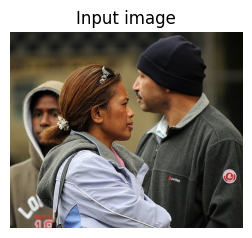

Text generated from model:
Three boys wearing glasses and glasses are holding something .


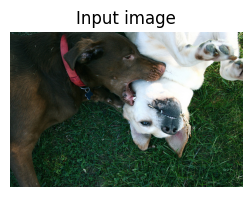

Text generated from model:
A brown dog with a red toy in its mouth is sniffing .


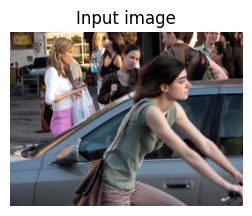

Text generated from model:
A group of people and a car


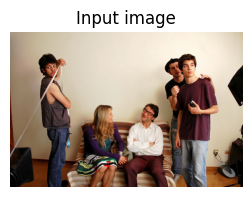

Text generated from model:
A girl wearing a white sweater and a red bandana is kissing a guy .


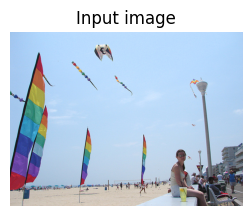

Text generated from model:
The girl is running through the air with her two children in tow .


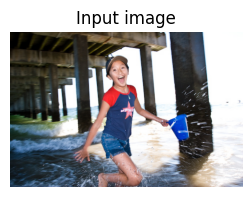

Text generated from model:
A child swimming in a pool .


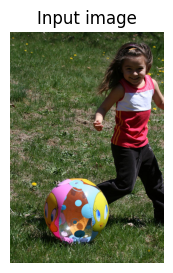

Text generated from model:
A young girl in a red dress is walking with a purple toy .


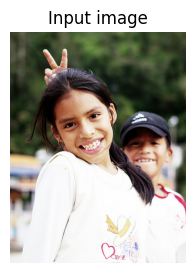

Text generated from model:
A man holds up a sign with a girl wearing a black head scarf .


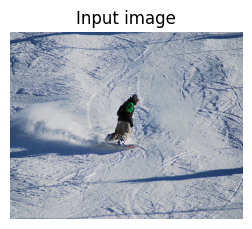

Text generated from model:
A man wearing a yellow shirt skis near a hill .


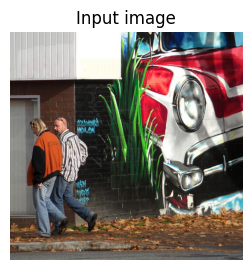

Text generated from model:
A group of people are sitting on a concrete wall and looking at the road .


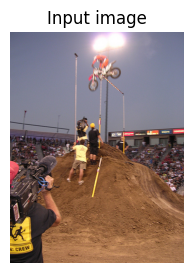

Text generated from model:
A person with an eye on another guy in the race .


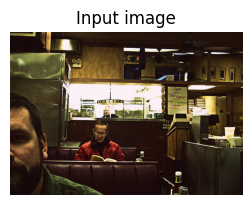

Text generated from model:
Two men sit on benches with their luggage and cups in their hands .


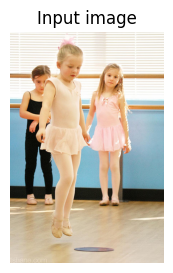

Text generated from model:
Woman in a white dress stands on a sidewalk wearing makeup and sunglasses .


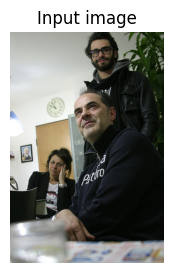

Text generated from model:
A group of people are gathered in a large room .


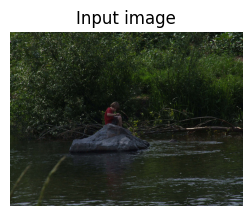

Text generated from model:
Two children stand in water while another man watches from behind .


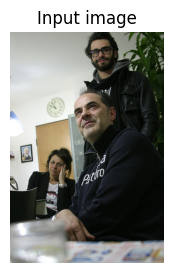

Text generated from model:
A man in a blue hat looking off and smiling .


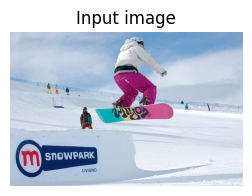

Text generated from model:
A person wearing a red and black jacket jumps over a metal obstacle .


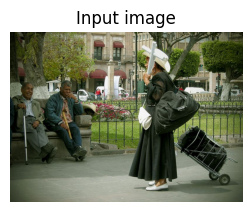

Text generated from model:
Two children play with each other on a street .


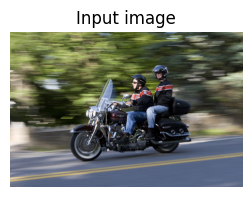

Text generated from model:
A group of people drive down the road of a red SUV .


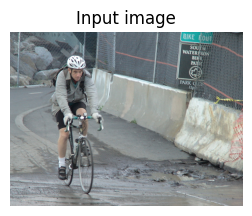

Text generated from model:
A bike rides around the park .


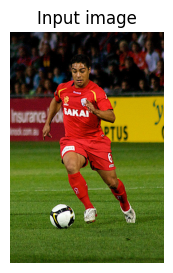

Text generated from model:
Two basketball players in orange and yellow are playing in the same field .


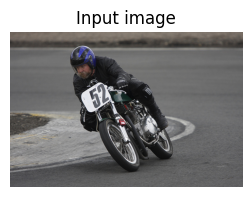

Text generated from model:
A guy is riding a dirt bike .


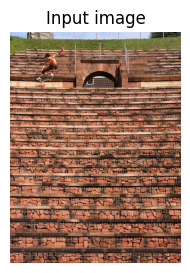

Text generated from model:
A black-haired man stands in the middle of the field .


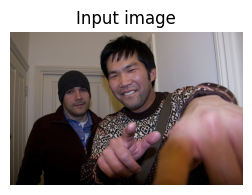

Text generated from model:
The older man is playing with his younger brother .


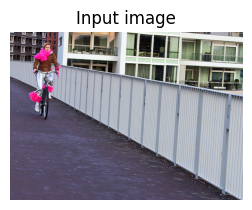

Text generated from model:
A child plays on a yellow roller coaster .


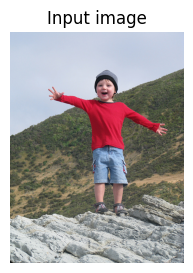

Text generated from model:
A boy in a striped shirt climbs a large stone wall


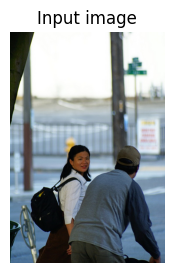

Text generated from model:
Two men and a woman stand on the sidewalk of a house in the middle of winter .


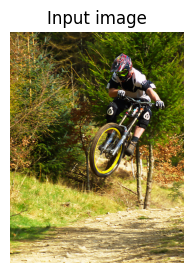

Text generated from model:
A cyclist is riding a biker through the woods .


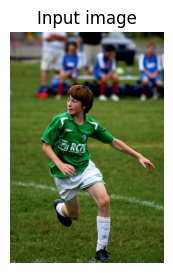

Text generated from model:
A little boy in a green jersey is playing with a yellow soccer ball .


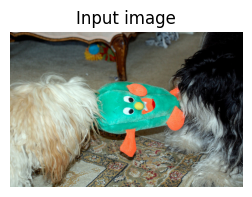

Text generated from model:
Two tan dogs play in a toy box .


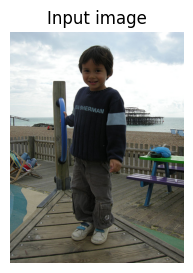

Text generated from model:
Two girls stand near a water tower


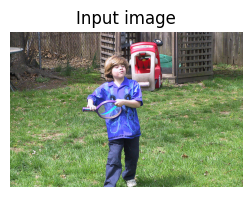

Text generated from model:
A girl throws a ball .


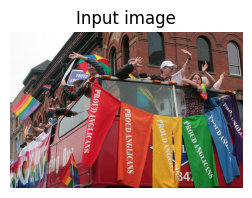

Text generated from model:
Two men in black , white , and green pants , look at the ceiling .


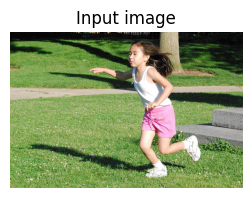

Text generated from model:
A girl wearing a red and green sweater is running next to a house .


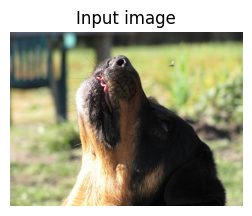

Text generated from model:
Two black dogs play in the grass .


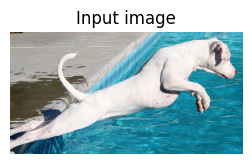

Text generated from model:
Two dogs jump into a pool .


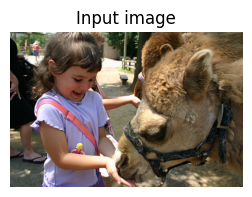

Text generated from model:
A man and two children are holding a basket of nuts on a horse .


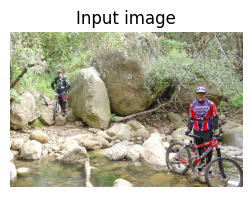

Text generated from model:
The group of people are camping in a rocky area with rocks , mountains and large trees in the background .


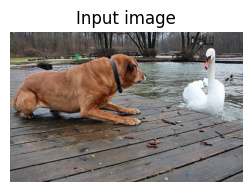

Text generated from model:
Two dogs are running through a garden .


In [19]:
# --- Test on a dataset image  ---
# Grab a sample from the same HF dataset
for i in range(1,40):
  idx = np.random.randint(0, len(hf_ds))
  sample = hf_ds[idx]
  pil_image = sample["image"]  # PIL.Image
  gen_text = generate_caption(
      model=gpt,
      tokenizer=tokenizer,
      pil_image=pil_image,
      max_new_tokens=48,
      temperature=1,
  )
  show_image_and_text(pil_image, gen_text)

## 15. Checkpoint Serialization

Save final trained model weights (`model_checkpoint.pth`), tokenizer files, and JSON configuration.


In [ ]:
# --- Model saving functions ---
def save_model_checkpoint(model, tokenizer, cfg, save_path, epoch=None, loss=None):
    os.makedirs(save_path, exist_ok=True)

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'config': cfg,
        'epoch': epoch,
        'loss': loss,
        'model_class': 'GPTModal',  # For reconstruction
    }

    # Save model checkpoint
    model_path = os.path.join(save_path, 'model_checkpoint.pth')
    torch.save(checkpoint, model_path)

    # Save tokenizer
    tokenizer_path = os.path.join(save_path, 'tokenizer')
    tokenizer.save_pretrained(tokenizer_path)

    # Save config as JSON for easy reading
    config_path = os.path.join(save_path, 'config.json')
    with open(config_path, 'w') as f:
        json.dump(cfg, f, indent=2)

    print(f"Model saved to: {save_path}")
    print(f"Files saved:")
    print(f"  - {model_path}")
    print(f"  - {tokenizer_path}/")
    print(f"  - {config_path}")

save_path = "./vision_gpt_model"
save_model_checkpoint(gpt, tokenizer, cfg, save_path, epoch=1, loss=None)
print("\nModel training and saving complete!")

Model saved to: ./vision_gpt_model
Files saved:
  - ./vision_gpt_model/model_checkpoint.pth
  - ./vision_gpt_model/tokenizer/
  - ./vision_gpt_model/config.json

Model training and saving complete!
